In [1]:
!pip install xgboost

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import time
from sklearn.model_selection import train_test_split

In [3]:
import requests 
def download_file(url,file_name): 
    response = requests.get(url) 
    if response.status_code == 200 : 
        with open(file_name , "wb") as f : 
            f.write(response.content)
            print("File successfuly written")

In [4]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UZPRFNucrENAFm25csq6eQ/California-housing.csv"

In [5]:
file_name = "California-housing.csv"
download_file(url,file_name)

File successfuly written


In [6]:
df = pd.read_csv(file_name)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
X = df.drop(["Target"], axis = 1) 
y = df["Target"]
X.shape
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42 )

In [9]:
N_observations, N_features = X.shape
print('Number of Observations: ' + str(N_observations))
print('Number of Features: ' + str(N_features))


Number of Observations: 20640
Number of Features: 8


In [10]:
#Initialize models 
n_estimators = 1000 
rf = RandomForestRegressor(n_estimators = n_estimators, random_state = 42)
xgb = XGBRegressor(n_estimators = n_estimators, random_state = 42)

In [12]:
#Fit models and measure training time
start_time_rf = time.time() 
rf.fit(X_train, y_train)
end_time_rf = time.time()
rf_train_time = end_time_rf - start_time_rf

start_time_xgb = time.time() 
xgb.fit(X_train, y_train)
end_time_xgb = time.time() 
xgb_train_time = end_time_xgb - start_time_xgb
print(f"Random forest training time :{rf_train_time:.9f}")
print(f" XGB training time :{xgb_train_time:.9f}")

Random forest training time :109.490135193
 XGB training time :1.976387739


In [15]:
#Measure prediction time for the above models
start_time_rf = time.time() 
y_pred_rf = rf.predict(X_test)
end_time_rf = time.time() 
rf_predict_time = end_time_rf - start_time_rf
start_time_xgb = time.time() 
y_pred_xgb = xgb.predict(X_test)
end_time_xgb = time.time() 
xgb_predict_time = end_time_xgb - start_time_xgb
print(f"Random forest prediction time :{rf_predict_time:.9f}")
print(f" XGB prediction time :{xgb_predict_time:.9f}")

Random forest prediction time :3.822800875
 XGB prediction time :0.030694008


In [16]:
#Calulate the MSE and R^2 values for both models
mse_rf = mean_squared_error(y_test, y_pred_rf)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_rf = r2_score(y_test, y_pred_rf)
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"Mse and r2 of random forest are {mse_rf}, {r2_rf} respectively")
print(f"Mse and r2 of XGB are {mse_xgb}, {r2_xgb} respectively")

Mse and r2 of random forest are 0.2516594547123297, 0.8079535023865917 respectively
Mse and r2 of XGB are 0.22595286361314315, 0.8275707299285575 respectively


In [17]:
std_y = np.std(y_test)

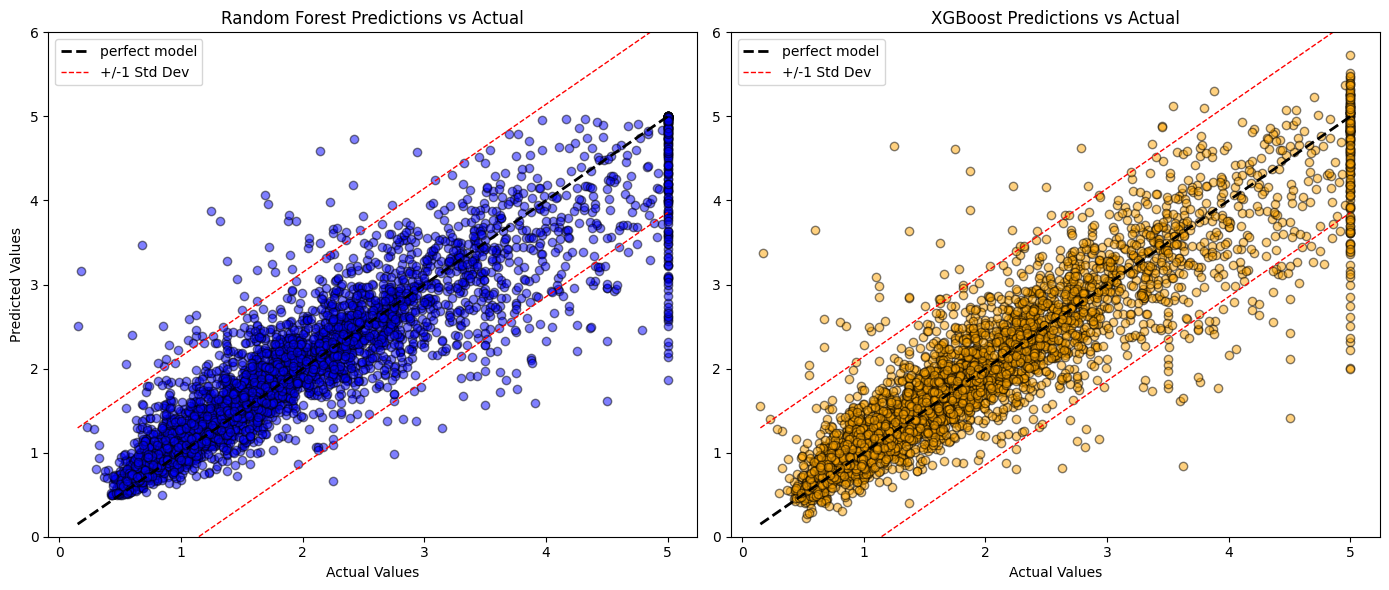

In [18]:
plt.figure(figsize=(14, 6))

# Random Forest plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_rf, alpha=0.5, color="blue",ec='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2,label="perfect model")
plt.plot([y_test.min(), y_test.max()], [y_test.min() + std_y, y_test.max() + std_y], 'r--', lw=1, label="+/-1 Std Dev")
plt.plot([y_test.min(), y_test.max()], [y_test.min() - std_y, y_test.max() - std_y], 'r--', lw=1, )
plt.ylim(0,6)
plt.title("Random Forest Predictions vs Actual")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()


# XGBoost plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_xgb, alpha=0.5, color="orange",ec='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2,label="perfect model")
plt.plot([y_test.min(), y_test.max()], [y_test.min() + std_y, y_test.max() + std_y], 'r--', lw=1, label="+/-1 Std Dev")
plt.plot([y_test.min(), y_test.max()], [y_test.min() - std_y, y_test.max() - std_y], 'r--', lw=1, )
plt.ylim(0,6)
plt.title("XGBoost Predictions vs Actual")
plt.xlabel("Actual Values")
plt.legend()
plt.tight_layout()
plt.show()